In [1]:
# ==========================================
# 1. PREPARACIÓN DEL ENTORNO
# ==========================================
using Pkg
Pkg.activate("/home/antonibancells/Desktop/Codi/TFM/ProvesModernes")

using ITensors
using ITensorMPS
using Plots

  Activating project at `~/Desktop/Codi/TFM/ProvesModernes`


El hamiltoniano del sistema viene dado por la expresión:
$$    H=J\sum_{i=1}^{N-1}\left[\frac{1}{2}\left(S_i^+ S^-_{i+1}+S^-_iS^+_{i+1} \right) +\Delta S_i^zS_{i+1}^z\right]+\sum_{i=1}^N h_i S_i^z=\sum_{i=1}^{N-1}\left(J\left[\frac{1}{2}\left(S_i^+ S^-_{i+1}+S^-_iS^+_{i+1} \right) +\Delta S_i^zS_{i+1}^z\right]+ h_i S_i^z\right)+h_N S_N^z=\sum_{i=1}^N H_i
$$ donde $J$ representa la constante de acoplamiento, $\Delta$ es el parámetro de anisotropía y $h_i$ es el campo magnético local. Se debe precisar que los términos de interacción local se definen como $H_i = J \left[ \frac{1}{2} ( S_i^+ S^-_{i+1} + S^-_i S^+_{i+1} ) + \Delta S_i^z S_{i+1}^z \right] + h_i S_i^z$ para $i=1,2,\dots,N$, mientras que el término del último sitio es simplemente $H_N = h_N S_N^z$.

In [2]:
# Definición de parámetros del modelo
  N = 100               # Número de sitios=espines
  J = 1.0               # Constante de acoplamiento
  Δ = 0.5               # Parámetro de anisotropía
  h = 1.0               # Campo magnético uniforme

1.0

In [3]:
# Configuración del espacio de Hilbert (espines 1/2). Usamos conserve_qns=true para aprovechar la conservación de Sz
  sites = siteinds("S=1/2", N; conserve_qns=true)

100-element Vector{Index{Vector{Pair{QN, Int64}}}}:
 (dim=2|id=90|"S=1/2,Site,n=1") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=466|"S=1/2,Site,n=2") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=89|"S=1/2,Site,n=3") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=938|"S=1/2,Site,n=4") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=275|"S=1/2,Site,n=5") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=309|"S=1/2,Site,n=6") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=653|"S=1/2,Site,n=7") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=388|"S=1/2,Site,n=8") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=556|"S=1/2,Site,n=9") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=99|"S=1/2,Site,n=10") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=936|"S=1/2,Site,n=11") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1
 (dim=2|id=128|"S=1/2,Site,n=12") <Out>
 1: QN("Sz",1) => 1
 2: QN("S

In [4]:
# Construcción del Hamiltoniano mediante OpSum (MPO)
  os = OpSum()
  for j in 1:(N - 1)
    # Términos de intercambio (hopping): 1/2 * (S+_j S-_{j+1} + S-_j S+_{j+1})
    os += 0.5 * J, "S+", j, "S-", j + 1
    os += 0.5 * J, "S-", j, "S+", j + 1
    # Término de anisotropía (interacción SzSz)
    os += J * Δ, "Sz", j, "Sz", j + 1
  end
  for j in 1:N
    # Término de campo magnético longitudinal
    os += h, "Sz", j
  end
  H = MPO(os, sites)

100-element MPO:
 ((dim=5|id=363|"Link,l=1") <Out>
 1: QN() => 1
 2: QN("Sz",0) => 1
 3: QN("Sz",-2) => 1
 4: QN("Sz",2) => 1
 5: QN("Sz",0) => 1, (dim=2|id=90|"S=1/2,Site,n=1")' <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=2|id=90|"S=1/2,Site,n=1") <In>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1)
 ((dim=5|id=363|"Link,l=1") <In>
 1: QN() => 1
 2: QN("Sz",0) => 1
 3: QN("Sz",-2) => 1
 4: QN("Sz",2) => 1
 5: QN("Sz",0) => 1, (dim=5|id=18|"Link,l=2") <Out>
 1: QN() => 1
 2: QN("Sz",0) => 1
 3: QN("Sz",-2) => 1
 4: QN("Sz",2) => 1
 5: QN("Sz",0) => 1, (dim=2|id=466|"S=1/2,Site,n=2")' <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=2|id=466|"S=1/2,Site,n=2") <In>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1)
 ((dim=5|id=18|"Link,l=2") <In>
 1: QN() => 1
 2: QN("Sz",0) => 1
 3: QN("Sz",-2) => 1
 4: QN("Sz",2) => 1
 5: QN("Sz",0) => 1, (dim=5|id=477|"Link,l=3") <Out>
 1: QN() => 1
 2: QN("Sz",0) => 1
 3: QN("Sz",-2) => 1
 4: QN("Sz",2) => 1
 5: QN("Sz",0) => 1, (dim=2|id=89|"S=1/2,Sit

In [5]:
# Estado inicial (MPS). Creamos un estado "Neel" o aleatorio que cumpla con el sector de QN deseado
# Aquí inicializamos con magnetización total cero (o la que prefieras)
  state = [isodd(n) ? "Up" : "Dn" for n in 1:N]
  psi0 = randomMPS(sites, state; linkdims=10)

100-element MPS:
 ((dim=2|id=90|"S=1/2,Site,n=1") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=2|id=940|"Link,l=1") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1)
 ((dim=2|id=466|"S=1/2,Site,n=2") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=4|id=840|"Link,l=2") <Out>
 1: QN("Sz",2) => 1
 2: QN("Sz",0) => 2
 3: QN("Sz",-2) => 1, (dim=2|id=940|"Link,l=1") <In>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1)
 ((dim=2|id=89|"S=1/2,Site,n=3") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=8|id=683|"Link,l=3") <Out>
 1: QN("Sz",3) => 1
 2: QN("Sz",1) => 3
 3: QN("Sz",-1) => 3
 4: QN("Sz",-3) => 1, (dim=4|id=840|"Link,l=2") <In>
 1: QN("Sz",2) => 1
 2: QN("Sz",0) => 2
 3: QN("Sz",-2) => 1)
 ((dim=2|id=938|"S=1/2,Site,n=4") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=10|id=816|"Link,l=4") <Out>
 1: QN("Sz",2) => 2
 2: QN("Sz",0) => 5
 3: QN("Sz",-2) => 3, (dim=8|id=683|"Link,l=3") <In>
 1: QN("Sz",3) => 1
 2: QN("Sz",1) => 3
 3: QN("Sz",-1) => 3
 4: QN("Sz",-3) => 1)

In [6]:
# Parámetros de los barridos (Sweeps)
# Definimos cómo aumentamos la precisión y la bond dimension (maxdim)
  sweeps = Sweeps(10)
  setmaxdim!(sweeps, 10, 20, 50, 100, 200) # Crecimiento progresivo de bond dimension
  setcutoff!(sweeps, 1E-10)

In [7]:
println("Iniciando DMRG para N=$N...")

# Ejecución del algoritmo DMRG
  energy, psi = dmrg(H, psi0, sweeps)

Iniciando DMRG para N=100...
After sweep 1 energy=-37.24940525167461  maxlinkdim=10 maxerr=3.88E-03 time=17.266
After sweep 2 energy=-37.32096254896461  maxlinkdim=20 maxerr=2.58E-06 time=0.534
After sweep 3 energy=-37.32746152091976  maxlinkdim=50 maxerr=1.34E-08 time=0.730
After sweep 4 energy=-37.32761768731847  maxlinkdim=96 maxerr=1.00E-10 time=1.058
After sweep 5 energy=-37.32761920054773  maxlinkdim=110 maxerr=9.99E-11 time=1.673
After sweep 6 energy=-37.32761920412138  maxlinkdim=108 maxerr=1.00E-10 time=1.172
After sweep 7 energy=-37.327619204146636  maxlinkdim=108 maxerr=9.99E-11 time=1.162
After sweep 8 energy=-37.327619204124254  maxlinkdim=108 maxerr=1.00E-10 time=1.161
After sweep 9 energy=-37.32761920412452  maxlinkdim=108 maxerr=1.00E-10 time=1.160
After sweep 10 energy=-37.32761920412528  maxlinkdim=108 maxerr=1.00E-10 time=1.190


(-37.32761920412528, MPS(100))

In [8]:
# Análisis de resultados
  println("="^51)
  println("Energía del estado fundamental: ", energy)
  println("="^51)


Energía del estado fundamental: -37.32761920412528


In [9]:
# Calculamos la magnetización local <Sz> en cada sitio
  magz = expect(psi, "Sz")
  
  println("\nDistribución de magnetización (primeros 10 sitios):")
  for i in 1:10
    println("Sitio $i: ", round(magz[i], digits=6))
  end


Distribución de magnetización (primeros 10 sitios):
Sitio 1: 0.0
Sitio 2: -0.0
Sitio 3: 0.0
Sitio 4: -0.0
Sitio 5: 0.0
Sitio 6: -0.0
Sitio 7: 0.0
Sitio 8: -0.0
Sitio 9: 0.0
Sitio 10: -0.0


In [10]:
# Entropía de entrelazamiento en el centro de la cadena
  orthogonalize!(psi, N ÷ 2)
  U, S, V = svd(psi[N ÷ 2], (siteind(psi, N ÷ 2), linkind(psi, N ÷ 2 - 1)))
  SvN = 0.0
  for n in 1:dim(S, 1)
    p = S[n, n]^2
    if p > 1E-12
      SvN -= p * log(p)
    end
  end
  println("\nEntropía de Von Neumann en el centro: ", SvN)


Entropía de Von Neumann en el centro: 0.9693083174951409


In [11]:
#La creación de los sites, la construcción del MPO y la solución por DMRG
#se puede integrar en una única función, en los que Delta es la anisotropía y h_profile 
#es un array que contiene un perfil de campo magnético
# Ambosentran como parámetros para realizar múltiples experimentos
# Devuelve como resultado la magnetización
function solve_dmrg(N, J,Δ, h_profile)
    sites = siteinds("S=1/2", N; conserve_qns=true)
    os = OpSum()
    for j in 1:(N - 1)
        os += 0.5*J, "S+", j, "S-", j + 1
        os += 0.5*J, "S-", j, "S+", j + 1
        os += J*Δ, "Sz", j, "Sz", j + 1
    end
    for j in 1:N
        os += h_profile[j], "Sz", j
    end
    H = MPO(os, sites)
    
    # Estado inicial (media magnetización para Sz=0)
    state = [isodd(n) ? "Up" : "Dn" for n in 1:N]
    psi0 = randomMPS(sites, state; linkdims=10)
    
    sweeps = Sweeps(10)
    setmaxdim!(sweeps, 10, 20, 50, 100)
    setcutoff!(sweeps, 1E-10)
    
    energy, psi = dmrg(H, psi0, sweeps)
    return expect(psi, "Sz")
end

solve_dmrg (generic function with 1 method)

In [12]:
# 1r ejemplo de prueba con campo uniforme (Temperatura constante de fondo)
    h_unif = fill(0.2, N)
    mag_unif = solve_dmrg(N, J,Δ, h_unif)

After sweep 1 energy=-37.281052885241856  maxlinkdim=10 maxerr=2.53E-03 time=0.444
After sweep 2 energy=-37.325957589671674  maxlinkdim=20 maxerr=2.36E-06 time=0.522
After sweep 3 energy=-37.32760489251481  maxlinkdim=50 maxerr=1.47E-08 time=0.720
After sweep 4 energy=-37.327619164414585  maxlinkdim=100 maxerr=1.76E-10 time=1.018
After sweep 5 energy=-37.327619200294585  maxlinkdim=100 maxerr=1.90E-10 time=1.140
After sweep 6 energy=-37.32761920027044  maxlinkdim=100 maxerr=1.84E-10 time=1.155
After sweep 7 energy=-37.327619200255114  maxlinkdim=100 maxerr=1.84E-10 time=1.188
After sweep 8 energy=-37.32761920025513  maxlinkdim=100 maxerr=1.84E-10 time=1.158
After sweep 9 energy=-37.327619200255285  maxlinkdim=100 maxerr=1.84E-10 time=1.155
After sweep 10 energy=-37.32761920025519  maxlinkdim=100 maxerr=1.84E-10 time=1.621


100-element Vector{Float64}:
  3.4449115782209105e-10
 -1.2168307333970674e-10
  3.5802801890728875e-10
 -1.0356480429104811e-10
  4.2449862290418624e-10
 -1.1015974767780653e-10
  4.411466887002108e-10
 -5.945604972026375e-11
  3.4534712715041416e-10
 -3.056049753485216e-11
  4.1447379977675893e-10
  1.3975521690746523e-10
  3.729717582177993e-10
  ⋮
  1.7391769014877588e-10
 -1.162010758002807e-10
  1.3064882648893068e-11
 -2.4286503595942975e-10
  1.5114407056144645e-10
 -2.9647922401165643e-10
  1.2789308339858831e-10
 -3.939219399903351e-10
  1.6325287539660034e-10
 -4.5677529580999757e-10
  1.536237491384096e-10
 -4.399062225601824e-10

In [13]:
# 2º ejemplo: Campo con un "pulso" central (Fuente de calor localizada)
    # Imaginamos una fuente de radiofrecuencia en el centro
    h_source = [0.2 + 1.0 * exp(-0.1 * (i - N/2)^2) for i in 1:N]
    mag_source = solve_dmrg(N, J,Δ, h_source)

After sweep 1 energy=-37.50472353432818  maxlinkdim=10 maxerr=2.62E-03 time=0.399
After sweep 2 energy=-37.673812491594965  maxlinkdim=20 maxerr=3.27E-06 time=0.533
After sweep 3 energy=-37.68411959626617  maxlinkdim=50 maxerr=4.17E-09 time=0.717
After sweep 4 energy=-37.68478341857236  maxlinkdim=99 maxerr=1.00E-10 time=0.964
After sweep 5 energy=-37.68480817778926  maxlinkdim=100 maxerr=1.97E-10 time=1.115
After sweep 6 energy=-37.68480867478188  maxlinkdim=100 maxerr=4.01E-10 time=1.121
After sweep 7 energy=-37.684808677138705  maxlinkdim=100 maxerr=1.78E-10 time=1.148
After sweep 8 energy=-37.684808677158735  maxlinkdim=100 maxerr=1.73E-10 time=1.186
After sweep 9 energy=-37.6848086771581  maxlinkdim=100 maxerr=1.73E-10 time=1.160
After sweep 10 energy=-37.68480867715808  maxlinkdim=100 maxerr=1.73E-10 time=1.646


100-element Vector{Float64}:
  0.032875586347463834
 -0.012236446190571708
  0.03735451162208914
 -0.016112028727484583
  0.03995991853978244
 -0.018389955926221082
  0.04162453367399925
 -0.019803208704978117
  0.04263885050181673
 -0.02059964979547923
  0.04313464756248339
 -0.02089655544107811
  0.04318530248118572
  ⋮
 -0.020149552123964826
  0.04094758107083971
 -0.01970679240177358
  0.04033688859146934
 -0.018827535695352345
  0.039271722768865744
 -0.017400973293992695
  0.03762733294424314
 -0.015192940230534684
  0.03512911755880708
 -0.011512504690794253
  0.030897878047023195

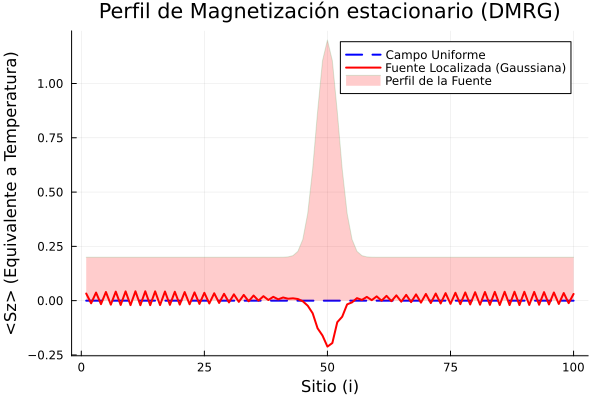

In [14]:
# Grafica de los resultados
    p = plot(1:N, [mag_unif, mag_source],
             label=["Campo Uniforme" "Fuente Localizada (Gaussiana)"],
             title="Perfil de Magnetización estacionario (DMRG)",
             xlabel="Sitio (i)",
             ylabel="<Sz> (Equivalente a Temperatura)",
             lw=2, linestyle=[:dash :solid],
             color=[:blue :red])
    
    # Añadimos el perfil del campo para ver la correspondencia
    plot!(p, 1:N, h_source , label="Perfil de la Fuente", 
          fill=(0, 0.2, :red), alpha=0.2)

    display(p)

La versión que se acaba de presentar asume que el sistema no tiene interacción con el entorno, es decir, que está aislado. En una analogía con la transferencia de calor, equivaldría a decir que en los dos expremos tenemos condiciones de Von Newman. Si se modifican los términos $H_1$ y $H_N$ del Hamiltoniano, sería el equivalente a los otros tipos de condiciones de contorno. Si en el site 1 tenemos un aislamiento parcial, que sería el equivalente a la condición de Robin, el termino $H_1$ se convierte en:
$$H_1=J_r \left(S_1^+ S_2^-+S_1^-S_2^+ +\Delta_r S_1^z\right)+h_e S_1^z$$
En cambio, si en el site $N$ se tiene lo que equivaldría a una condición de Dirichlet, lo que se modifica es el campo magnético local,que toma un valor $h_f$, mayor que los del resto de nodos, de manera que el término $H_N$ se convierte en: 
$$H_N=h_f S_N^z$$


In [15]:
# Función para resolver DMRG con un parámetro de anisotropia Delta y un array de campo magnético h_profile 
# Se añaden también condiciones de frontera, "ROBIN" en el sitio 1 y "DIRICHLET" en el sitio N
# Devuelve como resultado la magnetización
function solve_dmrg_bc(N, J,Δ, h_profile)

sites = siteinds("S=1/2", N; conserve_qns=true)

os = OpSum()

# CAMPOS LOCALES EN TODA LA CADENA 
for j in 1:N
    # Aplicamos el perfil. Si en los bordes h_profile es 0, 
    # se sumará a los campos de Robin/Dirichlet que vienen luego.
    os += h_profile[j], "Sz", j
end

# INTERACCIONES DEL CUERPO (Bulk)
for j in 2:(N - 2)
    os += 0.5 * J, "S+", j, "S-", j+1
    os += 0.5 * J, "S-", j, "S+", j+1
    os += J * Δ, "Sz", j, "Sz", j+1
end

# PARÁMETROS DE FRONTERA
J_robin = 0.5 * J  
Δ_robin = 0.8 * Δ  
h_ext = 0.2        
h_fixed = 5.0    
    
# CONDICIONES DE FRONTERA (Robin y Dirichlet)
# Robin en el sitio 1 (enlace 1-2)
os += h_ext, "Sz", 1
os += 0.5 * J_robin, "S+", 1, "S-", 2
os += 0.5 * J_robin, "S-", 1, "S+", 2
os += J_robin * Δ_robin, "Sz", 1, "Sz", 2

# Dirichlet en el sitio N (enlace N-1 a N)
os += h_fixed, "Sz", N
os += 0.5 * J, "S+", N-1, "S-", N
os += 0.5 * J, "S-", N-1, "S+", N
os += J * Δ, "Sz", N-1, "Sz", N
    
H = MPO(os, sites)
    
# Estado inicial (media magnetización para Sz=0)
state = [isodd(n) ? "Up" : "Dn" for n in 1:N]
psi0 = randomMPS(sites, state; linkdims=10)
    
sweeps = Sweeps(10)
setmaxdim!(sweeps, 10, 20, 50, 100)
setcutoff!(sweeps, 1E-10)
    
energy, psi = dmrg(H, psi0, sweeps)
return expect(psi, "Sz")
    
end

solve_dmrg_bc (generic function with 1 method)

In [16]:
#Primer ejemplo con condiciones de contorno
mag_unif_bc = solve_dmrg_bc(N, J,Δ, h_unif)

After sweep 1 energy=-39.10140041252968  maxlinkdim=10 maxerr=2.26E-03 time=0.411
After sweep 2 energy=-39.28463150046294  maxlinkdim=20 maxerr=2.34E-06 time=0.541
After sweep 3 energy=-39.28907568713371  maxlinkdim=50 maxerr=2.24E-08 time=0.746
After sweep 4 energy=-39.2891427083855  maxlinkdim=100 maxerr=1.65E-10 time=0.993
After sweep 5 energy=-39.289143206942306  maxlinkdim=100 maxerr=1.89E-10 time=1.153
After sweep 6 energy=-39.28914320773758  maxlinkdim=100 maxerr=1.78E-10 time=1.151
After sweep 7 energy=-39.28914320777528  maxlinkdim=100 maxerr=1.79E-10 time=1.140
After sweep 8 energy=-39.28914320777852  maxlinkdim=100 maxerr=1.79E-10 time=1.150
After sweep 9 energy=-39.289143207773414  maxlinkdim=100 maxerr=1.79E-10 time=1.154
After sweep 10 energy=-39.28914320777331  maxlinkdim=100 maxerr=1.79E-10 time=1.561


100-element Vector{Float64}:
 -0.34329062767490776
  0.11032224967556156
 -0.07706755312450626
  0.07929493180039936
 -0.058118124044036774
  0.06507748386642577
 -0.04716733496874577
  0.05609573775684481
 -0.03966082697953665
  0.04963620970636803
 -0.034012515291187234
  0.04461949057299053
 -0.029493249243713715
  ⋮
  0.05209945241057005
 -0.041904985525541685
  0.058229238391906316
 -0.04915323011182841
  0.0671117739800559
 -0.06022893529534964
  0.08176505395093604
 -0.08018623045079763
  0.1122299186778435
 -0.13015905704005085
  0.22438256024922945
 -0.4939039823980759

In [17]:
#2º ejemplo con condiciones de contorno
mag_source_bc = solve_dmrg_bc(N, J,Δ, h_source)

After sweep 1 energy=-39.469008826677246  maxlinkdim=10 maxerr=4.70E-03 time=0.398
After sweep 2 energy=-39.600926404305845  maxlinkdim=20 maxerr=2.16E-06 time=0.512
After sweep 3 energy=-39.607401532325504  maxlinkdim=50 maxerr=2.14E-08 time=0.714
After sweep 4 energy=-39.607647581721004  maxlinkdim=100 maxerr=1.74E-10 time=0.964
After sweep 5 energy=-39.60765361415536  maxlinkdim=100 maxerr=2.47E-10 time=1.107
After sweep 6 energy=-39.60765364670391  maxlinkdim=100 maxerr=1.90E-10 time=1.138
After sweep 7 energy=-39.607653646658726  maxlinkdim=100 maxerr=1.90E-10 time=1.133
After sweep 8 energy=-39.60765364668258  maxlinkdim=100 maxerr=1.90E-10 time=1.168
After sweep 9 energy=-39.60765364668253  maxlinkdim=100 maxerr=1.90E-10 time=1.185
After sweep 10 energy=-39.60765364668244  maxlinkdim=100 maxerr=1.90E-10 time=1.178


100-element Vector{Float64}:
 -0.28948329870920586
  0.11528885018227016
 -0.061229910988294715
  0.0835830874629924
 -0.039148937082132206
  0.06567460052517295
 -0.023826427917916844
  0.05217503379601311
 -0.011557269618085652
  0.040963902353059224
 -0.001132432143775609
  0.031288456841860525
  0.00792271872423812
  ⋮
  0.05832493141958962
 -0.0298010051537111
  0.06900540742008403
 -0.041459385786133854
  0.0819083280274612
 -0.056342566274256954
  0.09976501216436272
 -0.07921592202006528
  0.13213975163116454
 -0.13073367977774075
  0.24346979176298725
 -0.49368496787172556

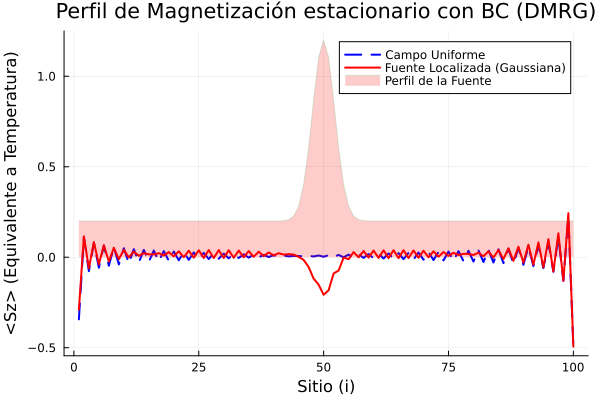

In [18]:
# Grafica de los resultados
    p = plot(1:N, [mag_unif_bc, mag_source_bc],
             label=["Campo Uniforme" "Fuente Localizada (Gaussiana)"],
             title="Perfil de Magnetización estacionario con BC (DMRG)",
             xlabel="Sitio (i)",
             ylabel="<Sz> (Equivalente a Temperatura)",
             lw=2, linestyle=[:dash :solid],
             color=[:blue :red])
    
    # Añadimos el perfil del campo para ver la correspondencia
    plot!(p, 1:N, h_source , label="Perfil de la Fuente", 
          fill=(0, 0.2, :red), alpha=0.2)

    display(p)